https://velog.io/@kungsboy/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D-12-01.%EC%95%99%EC%83%81%EB%B8%94Ensemble-Bagging-%EC%95%99%EC%83%81%EB%B8%94-%EB%AA%A8%EB%8D%B8

In [11]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

In [12]:
from sklearn.tree import DecisionTreeClassifier

base_model = DecisionTreeClassifier(random_state=42)

In [13]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = BaggingClassifier(
    estimator=base_model,
    n_estimators=50,   # 모델 개수
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, average='macro'))
print("Recall:", recall_score(y_test, pred, average='macro'))
print("F1:", f1_score(y_test, pred, average='macro'))

print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [15]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 시각화를 위해 2개 feature만 사용
X = X[['petal length (cm)', 'petal width (cm)']]

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

base_model = DecisionTreeClassifier(random_state=42)

# 복원추출로 만든 데이터셋 50개로 각각 모델을 학습하는 구조
model = BaggingClassifier(
    estimator=base_model,
    n_estimators=50,
    random_state=42
)
# 🌳 2. 진짜 내부 구조
# Tree 1 → 데이터 샘플 A
# Tree 2 → 데이터 샘플 B
# Tree 3 → 데이터 샘플 C
# ...
# Tree 50 → 데이터 샘플 Z

# Model 1 → setosa
# Model 2 → versicolor
# Model 3 → versicolor
# Model 4 → virginica
# Model 5 → versicolor

model.fit(X_train, y_train)

# 🔥 7. 핵심 정리

# 👉 Bagging 샘플링 핵심:

# 데이터 전체 크기만큼 뽑음
# 복원추출이라 중복 발생
# 평균적으로 63%만 unique 데이터
# 나머지 37%는 OOB 데이터

# 🚀 한 줄 요약
# 👉 Bagging은 “전체 크기만큼 복원추출”하며, 약 63%만 새로운 데이터가 된다

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, random_state=42)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(


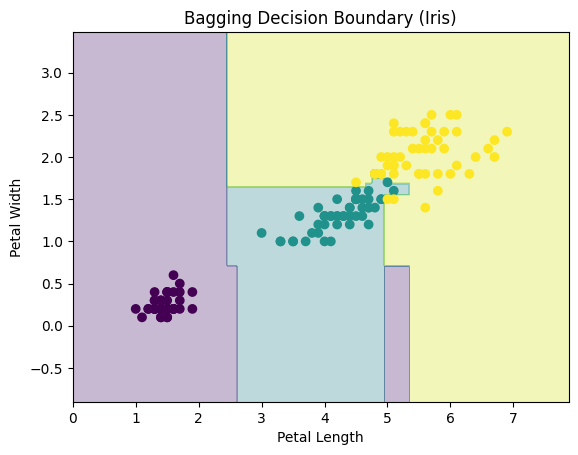

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Bagging Decision Boundary (Iris)")

plt.show()